Combinazione Regressioni

Combiniamo lre regressioni lineare e logistica
Vediamo come cambia il modello

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression

In [5]:
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name="target")
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
y.describe()

count    569.000000
mean       0.627417
std        0.483918
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

Selezioniamo una sola feature (mean radius, media del raggio del tumore)

In [10]:

X_sel=X[["mean radius"]]
print(X_sel.shape)
lin_reg=LinearRegression()
lin_reg.fit(X_sel,y)

y_lin=lin_reg.predict(X_sel)


(569, 1)


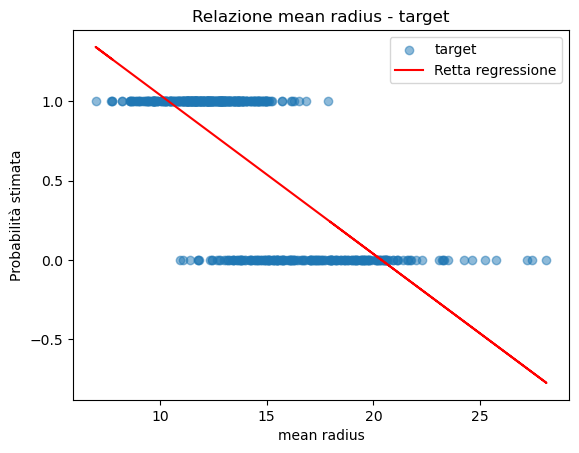

In [12]:
plt.scatter(X_sel,y,label="target",alpha=0.5)
plt.plot(X_sel,y_lin, color="red", label="Retta regressione")
plt.xlabel("mean radius")
plt.ylabel("Probabilità stimata")
plt.title("Relazione mean radius - target")
plt.legend()
plt.show()

In [18]:
X_new=X.copy()
X_new["lin_pred"]=y_lin
log_reg=LogisticRegression(max_iter=1000,random_state=42)
log_reg.fit(X_new,y)
y_pred=log_reg.predict(X_new)

corrette=np.sum(y==y_pred)
tot=len(y)
accurancy=corrette/tot
print(f"Etichette corrette: {corrette}/{tot}")
print(f"Accuracy: {accurancy*100:.2f}%")


Etichette corrette: 547/569
Accuracy: 96.13%


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


con le 1000 iterazioni imposte al modello, il modello ritorna un messaggio che dice che non è riscito a convergere dopo 1000 iterzioni e da due consigli: 1) aumentare il numero di iterazioni 2) scalare i dati
Proviamo a scalare i dati

In [19]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_new)

log_reg_scaled=LogisticRegression(max_iter=1000,random_state=42)
log_reg_scaled.fit(X_scaled,y)

y_pred_scaled=log_reg_scaled.predict(X_scaled)

corrette_scaled=np.sum(y==y_pred_scaled)
tot_scaled=len(y)
accurancy_scaled=corrette_scaled/tot_scaled
print(f"Etichette corrette: {corrette}/{tot}")
print(f"Accuracy: {accurancy_scaled*100:.2f}%")


Etichette corrette: 547/569
Accuracy: 98.77%


Accuracy è migliorata ed ora 1000 iterazioni sono bastate

In [20]:
print(log_reg_scaled.n_iter_)

[18]


Siamo passati da + di 1000 iterazioni richieste a 18 dopo aver fatto StandardScaler

Vediamo come sono distribuiti gli errori

C:\Users\uberti\AppData\Local\Temp\ipykernel_8340\45859686.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


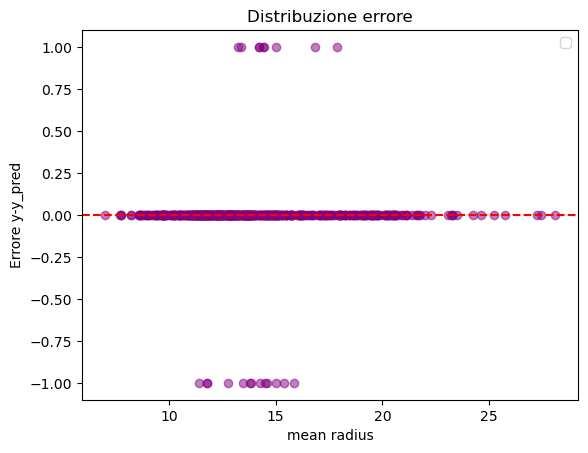

In [22]:
plt.scatter(X_sel,y-y_pred,alpha=0.5,color="purple")
plt.axhline(0,color="red",linestyle="--") #linea 0 con errore nullo
plt.xlabel("mean radius")
plt.ylabel("Errore y-y_pred")
plt.title("Distribuzione errore")
plt.legend()
plt.show()

La maggior parte dei punti sono stati classificati (con regressione logistica) perfettamente, perchè cadono sulla retta rossa (y=0), e solo pochi punti sono stati mal classificati 

Grafico a barre per differenza tra accuracy con e senza standarizzazione

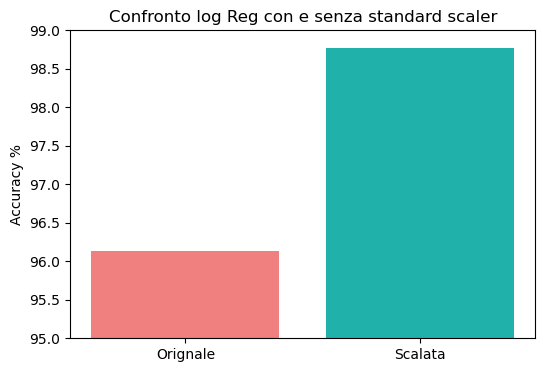

In [25]:
plt.figure(figsize=(6,4))
plt.bar([
    "Orignale","Scalata"], 
    [accurancy*100,accurancy_scaled*100],
    color=["lightcoral","lightseagreen"]
    )
plt.ylabel("Accuracy %")
plt.title("Confronto log Reg con e senza standard scaler")
plt.ylim(95,99)
plt.show()